# Assess the Exploration 


In this notebook we inspect the training state via: 
1. Reward as function of episodes with smoothing-window function. 
2. Reward as function of time evolution within an episode 
3. Actor and critic loss during exploration. 

In [1]:
%matplotlib inline
import numpy as np  
import os 
import matplotlib.pyplot as plt 
import pandas as pd 
from postlib.plot import plt_setUp, colorplate as cc
from postlib.explore import * 
import datetime
# Environment 
color_list = [cc.deepgreen,cc.deepblue,cc.deeppurple,cc.orange,cc.yellow,cc.red,cc.blue,cc.yellow2,cc.lightblue,cc.pink,cc.darkred]
plt_setUp()
run_path = "../runs"
fig_path = "Figs"
SAVE_IMG = False
if not os.path.exists(fig_path):
    os.makedirs(fig_path)


## Add your case

In [2]:
# Case list 
case_tuple = [
            (304001, "DDPG-1e8-1"), 
            (304002, "DDPG-1e8-2"),
            (304011, "DDPG-2e8-1"),
            (304012, "DDPG-2e8-2"),
            (304021, "DDPG-2utau-1"),
            (304022, "DDPG-2utau-2"),
            ]
case_list = [case_tuple[i][0] for i in range(len(case_tuple))]
case_name = [case_tuple[i][1] for i in range(len(case_tuple))]
case_dict = initalize_case(run_path,case_list)
            

---- Start Case 1 ----
Reward list: 31 files
Reward smooth: (70001,)
Reward mean max R: 20.92 at episode 22
---- End ----

---- Start Case 2 ----
Reward list: 51 files
Reward smooth: (117501,)
Reward mean max R: 24.48 at episode 32
---- End ----

---- Start Case 3 ----
Reward list: 17 files
Reward smooth: (37501,)
Reward mean max R: 16.54 at episode 5
---- End ----

---- Start Case 4 ----
Reward list: 51 files
Reward smooth: (117501,)
Reward mean max R: 27.16 at episode 34
---- End ----

---- Start Case 5 ----
Reward list: 17 files
Reward smooth: (37501,)
Reward mean max R: 1.55 at episode 7
---- End ----

---- Start Case 6 ----
Reward list: 17 files
Reward smooth: (37501,)
Reward mean max R: 28.85 at episode 11
---- End ----



## Reward evolution as function of epsiode with smooth func
+ Using a convolution to smooth the reward evolution step by step. 
+ Depict the continuous evolution of reward throughout the exploration.  

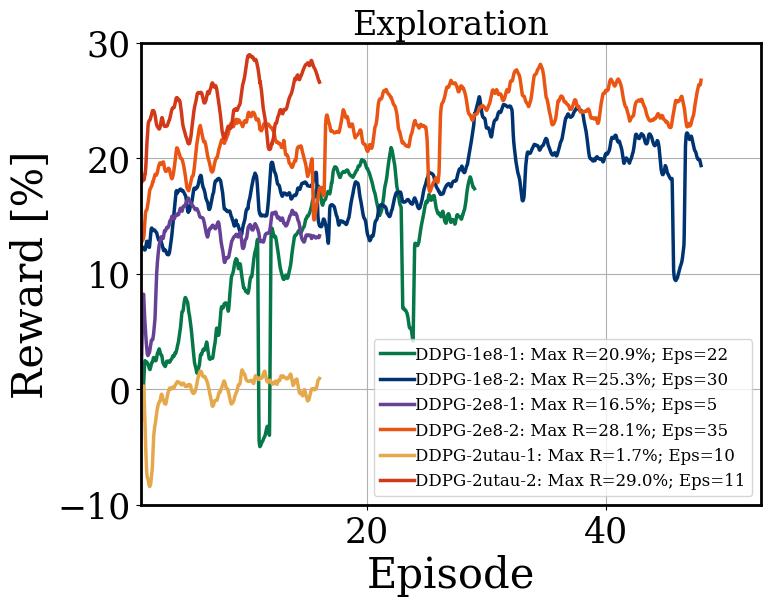

In [3]:

fig,axs = plt.subplots(1,1,figsize=(8,6))

eps_max = -1 
for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_smooth_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_smooth_max_index'])
    axs.plot(case_dict[case]['episode'], case_dict[case]['reward_smooth'],lw=2.5,c=color_list[il],label=label)

    # better visualization
    len_eps = np.max(case_dict[case]['episode'])
    if eps_max < len_eps: 
        eps_max = len_eps 
        
axs.set_xlabel("Episode",)
axs.set_ylabel("Reward [%]",)
axs.set_ylim(-10,30); axs.set_xlim(1,np.ceil(1.1*eps_max))
axs.set_title("Exploration",)
axs.grid(True)
axs.legend(loc='lower right',prop={'size': 12})
plt.show()
if SAVE_IMG: 
    plt.savefig(f"{fig_path}/reward_smooth_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

## Mean Reward Evolution
+ No sliding-window smoother.
+ Depict the evolution of mean reward of each epiosde
+ Useful to select the best model

Case-304001: current R=17.36%
Case-304002: current R=19.36%
Case-304011: current R=13.28%
Case-304012: current R=26.76%
Case-304021: current R=0.93%
Case-304022: current R=26.58%


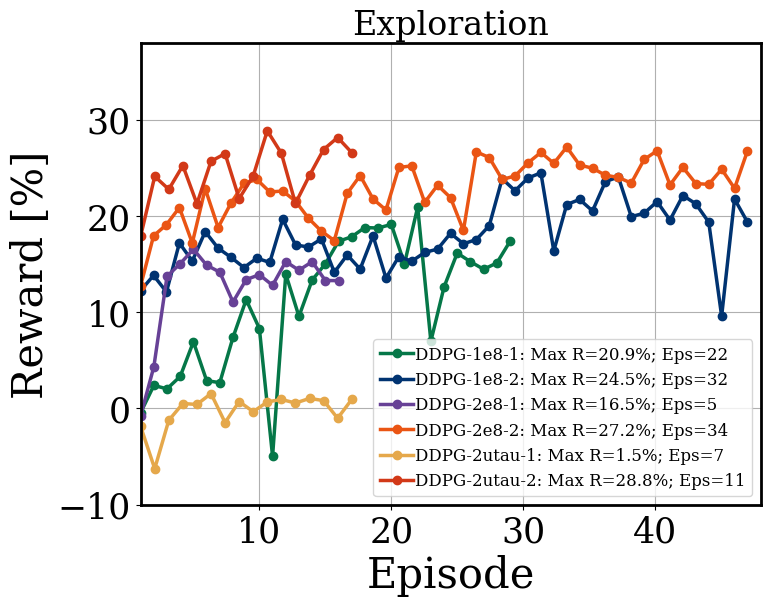

In [4]:

fig,axs = plt.subplots(1,1,figsize=(8,6))

eps_max = -1
rew_max = -1.0 
for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_mean_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_max_index'])
    axs.plot(case_dict[case]['episode_idx'], case_dict[case]['reward_mean'],
             marker='o',
             lw=2.5,c=color_list[il],label=label)

    print(f"Case-{case}: current R={case_dict[case]['reward_mean'][-1]:.2f}%") 
    
    # better visualization
    len_eps = np.max(case_dict[case]['episode_idx'])
    if eps_max < len_eps: 
        eps_max = len_eps 
    if rew_max < case_dict[case]['reward_mean_max']:
        rew_max  = case_dict[case]['reward_mean_max']

axs.set_xlabel("Episode",); axs.set_ylabel("Reward [%]",)
axs.set_ylim(-10,np.ceil(rew_max*1.3));axs.set_xlim(1,np.ceil(1.01*eps_max))
axs.set_title("Exploration",)
axs.grid(True)
axs.legend(loc='lower right',prop={'size': 12})
plt.show()
if SAVE_IMG: 
    plt.savefig(f"{fig_path}/reward_smooth_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

## Actor and Critic Loss on training

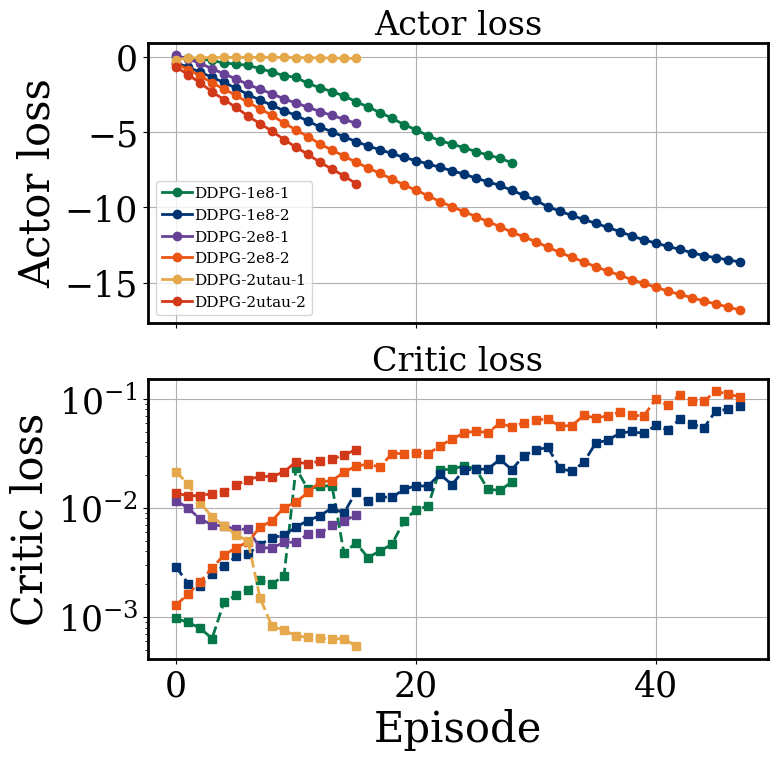

In [5]:
fig,axs = plt.subplots(2,1,figsize=(8,8),sharex=True)
for il, case in enumerate(case_list):
    label = case_name[il] 
    axs[0].plot(case_dict[case]['actor_loss'],ls='-',marker='o',lw=2.0,c=color_list[il],label=label)
    axs[1].semilogy(case_dict[case]['critic_loss'],ls='--',marker='s',lw=2.0,c=color_list[il],label=label)

axs[1].set_xlabel("Episode",)
axs[0].set_ylabel("Actor loss",)
axs[1].set_ylabel("Critic loss",)
axs[0].set_title("Actor loss",)
axs[1].set_title("Critic loss",)
axs[0].grid(True)
axs[1].grid(True)
axs[0].legend(loc='lower left',prop={'size': 11})
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/loss_episode_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)



## (Optional) The reward evolution during an episode

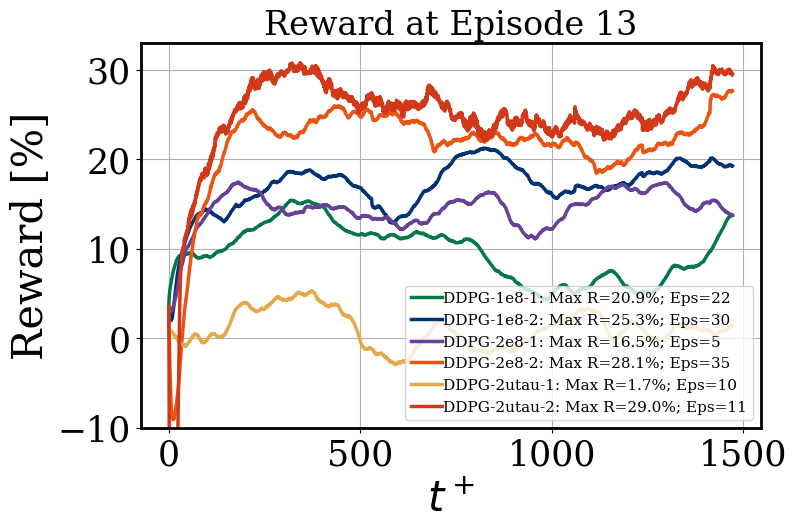

In [6]:
EPISODE_ID = 12; max_rew = -1000 
fig,axs = plt.subplots(1,1,figsize=(8,5))


for il, case in enumerate(case_list):
    label = case_name[il] 
    label = label + ": Max R={:.1f}%".format(case_dict[case]['reward_smooth_max'])
    label = label + "; Eps={}".format(case_dict[case]['reward_smooth_max_index'])
    # Get the time scale 
    u_tau = case_dict[case]['conf']['runner']['u_tau'] 
    Reb = 1./ np.abs(case_dict[case]['conf']['simulation']['viscosity'])
    t_star = Reb / u_tau**2
    #print(f"Reb = {Reb}, u_tau = {u_tau}, t_star = {t_star}")
    DT = np.abs(case_dict[case]['conf']['simulation']['dt'])
    ndrl = case_dict[case]['conf']['simulation']['ndrl']
    NSTEP = case_dict[case]['conf']['runner']['nb_interactions']
    TEND = NSTEP * DT * ndrl   
    t     = np.linspace(0,TEND,NSTEP)
    tplus = t/t_star
    try: 
        episode_data = case_dict[case]['reward'][EPISODE_ID][:]
        axs.plot(tplus[:NSTEP],episode_data,c=color_list[il],lw=2.5,label=label)

        if max_rew < np.max(episode_data): 
            max_rew = np.max(episode_data)
    except: 
        print(f'No data for {EPISODE_ID}')
        
axs.set_xlabel(r"$t^+$",)
axs.set_ylabel("Reward [%]",)
axs.set_title(f"Reward at Episode {EPISODE_ID+1}",)
axs.grid(True)
axs.set_ylim(-10,np.ceil(max_rew*1.05))
axs.legend(loc='lower right',prop={'size': 11})
plt.show()
if SAVE_IMG:
    plt.savefig(f"{fig_path}/reward_one_episode_{EPISODE_ID}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png",dpi=299)

